---
title: "客户分群案例"
author: "KaisMemo"
date: "2026-03-14"
categories: [data analysis, e-commerce, customer segmentation, RFM]
---

**数据来源**：[2010-2011 年间英国某在线零售商的所有真实交易](https://www.kaggle.com/datasets/carrie1/ecommerce-data/data)

其中包含一家英国在线零售商在 2010 年 12 月 1 日至 2011 年 12 月 9 日期间发生的所有交易。该公司主要销售全场合礼品，且许多客户都是批发商。

# 数据准备

引入需要的库。

In [ ]:
import chardet as cd
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plot

推断数据编码。

In [89]:
# detect the encoding
with open('./dataset/data.csv', 'rb') as raw_data:
    encoding_detected = cd.detect(raw_data.read(20000))
print(encoding_detected)

{'encoding': 'Windows-1252', 'confidence': 1.0, 'language': 'en'}


读取数据。

In [90]:
# read the dataset
data_origin = pd.read_csv('./dataset/data.csv', encoding=encoding_detected['encoding'], dtype={'CustomerID': str,'InvoiceNo': str})
display(data_origin)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680,France


## 处理重复值

In [91]:
# handle the duplicated values
count_duplicated = data_origin.duplicated().sum()
data_origin.drop_duplicates(inplace=True)
print(f'{count_duplicated} duplicated entries been dropped.')

5268 duplicated entries been dropped.


## 处理缺失值

In [92]:
# handle the null value
count_null = data_origin.isna().sum()
pd.DataFrame({
    'columns': data_origin.columns,
    'null(n)': count_null,
    'null(%)': round(((count_null / data_origin.count()) * 100), 1)
}).T

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
columns,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
null(n),0,0,1454,0,0,0,135037,0
null(%),0.0,0.0,0.3,0.0,0.0,0.0,33.6,0.0


从语义上讲，`CustomerID` 无法以任何方式进行推断填充。所以把此列为空的行直接删除。

In [93]:
# drop the rows with null CustomerID
count_null_customer_id = count_null['CustomerID']
data_origin.dropna(subset=['CustomerID'], inplace=True)
print(f'{count_null_customer_id} entries with null CustomerID been dropped.')

count_null = data_origin.isna().sum()
pd.DataFrame({
    'columns': data_origin.columns,
    'null(n)': count_null,
    'null(%)': round(((count_null / data_origin.count()) * 100), 1)
}).T

135037 entries with null CustomerID been dropped.


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
columns,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
null(n),0,0,0,0,0,0,0,0
null(%),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 处理数据类型

In [94]:
# check dtypes
data_origin.dtypes

InvoiceNo          str
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
UnitPrice      float64
CustomerID         str
Country            str
dtype: object

`InvoiceDate` 应该是日期。

In [95]:
data_origin['InvoiceDate'] = pd.to_datetime(data_origin['InvoiceDate'])
data_origin.dtypes

InvoiceNo                 str
StockCode                 str
Description               str
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID                str
Country                   str
dtype: object

初步数据清洗结束。

In [96]:
display(data_origin)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680,France


# 探索数据内容

数据集有 8 个维度。根据列名初步推测业务语义：

1. `InvoiceNo`：发票号。分配给每笔交易的 6 位唯一整数。
2. `StockCode`：产品（商品）代码。分配给每种产品的 5 位唯一整数。
3. `Description`：产品（条目）名称。
4. `Quantity`：每次交易每种产品（商品）的数量。
5. `InvoiceDate`：每笔交易生成的日期和时间。
6. `UnitPrice`：单价。每单位产品价格（以英镑为单位）。
7. `CustomerID`：客户编号。分配给每个客户的 5 位唯一整数。
8. `Country`：国家名称。每个客户居住的国家/地区的名称。

## 数值型维度洞察

检查数值型维度的分布情况。

In [97]:
# check numeric dimensions distribution
data_numeric = data_origin.select_dtypes(['int64', 'float64'])
data_numeric.describe()

,Quantity,UnitPrice
count,401604.000000,401604.000000
mean,12.183273,3.474064
std,250.283037,69.764035
min,-80995.000000,0.000000
25%,2.000000,1.250000
50%,5.000000,1.950000
75%,12.000000,3.750000
max,80995.000000,38970.000000


发现 `Quantity` 有非法负值，且两个维度都有极端立群值。

简单浏览这些行。

In [98]:
# negative quantity
negative_quantity_mask = data_numeric['Quantity'] < 0
data_negative_quantity = data_origin[negative_quantity_mask]
display(data_negative_quantity)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548,United Kingdom
...,...,...,...,...,...,...,...,...
540449,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,2011-12-09 09:57:00,0.83,14397,United Kingdom
541541,C581499,M,Manual,-1,2011-12-09 10:28:00,224.69,15498,United Kingdom
541715,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,2011-12-09 11:57:00,10.95,15311,United Kingdom
541716,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,2011-12-09 11:58:00,1.25,17315,United Kingdom


`Quantity` 为负值的行，看起来代表了某种业务语义。不妨推测：

- **H1**：负值库存对应的 `InvoiceNo` 可能全部以 “C” 开头，反之亦然
- **H2**：“C” 可能代表 “Cancel”，代表该笔交易被取消

In [99]:
# check if InvoiceNo all start with 'C'
count_negative_quantity = len(data_negative_quantity)
count_c_prefix_invoice_no = data_origin['InvoiceNo'].str.startswith('C').sum()
print('if all negative quantity entries have a InvoiceNo start with \'C\', vice versa?', count_negative_quantity == count_c_prefix_invoice_no)

if all negative quantity entries have a InvoiceNo start with 'C', vice versa? True


H1 成立。

In [100]:
# check if ‘C’ means ‘Cancel’
data_test_cancel = data_origin[['StockCode', 'Quantity', 'InvoiceDate', 'CustomerID']]
data_test_cancel.sort_values(by=['CustomerID', 'StockCode', 'InvoiceDate'])
data_test_cancel['StockCumSum'] = data_test_cancel.groupby(['CustomerID', 'StockCode'])['Quantity'].cumsum()

def verify_row(row):
    if row['Quantity'] >= 0:
        return 'Normal Sale'
    elif row['StockCumSum'] >= 0:
        return 'Valid Return'
    else:
        return 'Orphan/Excess Return'

data_test_cancel['ValidationStatus'] = data_test_cancel.apply(verify_row, axis='columns')
count_status = data_test_cancel['ValidationStatus'].value_counts()
pd.DataFrame({
    'n': count_status,
    '%': round(((count_status / len(data_test_cancel)) * 100), 1)
}).T

ValidationStatus,Normal Sale,Valid Return,Orphan/Excess Return
n,392732.0,7462.0,1410.0
%,97.8,1.9,0.4


H2 不成立。看看是哪些负值数量行没有对应的正向销售订单。

In [101]:
# check rows mismatched the negative counterpart
invalid_orders = data_origin[data_test_cancel['ValidationStatus'] == 'Orphan/Excess Return']
display(invalid_orders)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548,United Kingdom
...,...,...,...,...,...,...,...,...
534308,C581145,M,Manual,-1,2011-12-07 13:48:00,9.95,17490,United Kingdom
536914,C581228,22781,GUMBALL MAGAZINE RACK,-24,2011-12-08 10:06:00,6.75,16019,United Kingdom
537496,C581305,22627,MINT KITCHEN SCALES,-1,2011-12-08 11:42:00,8.50,16933,United Kingdom
537601,C581323,21533,RETROSPOT LARGE MILK JUG,-1,2011-12-08 11:53:00,4.25,14442,Channel Islands


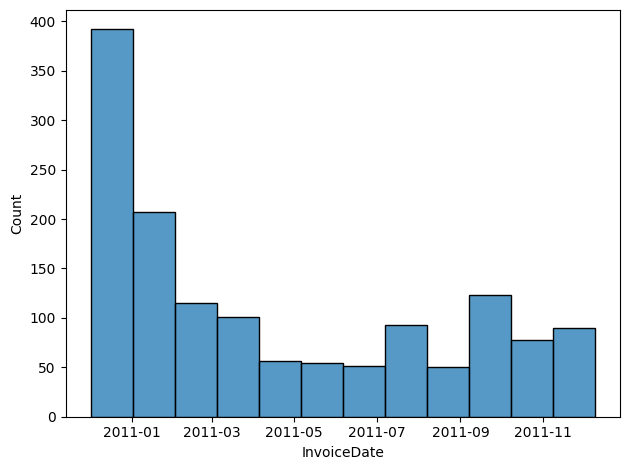

In [102]:
sb.histplot(invalid_orders['InvoiceDate'], bins=12)
plot.tight_layout()
plot.show()

可以观察到，大部分孤儿订单集中在数据集的初期，判断可能是因为对应的正向销售订单比较早，没有包含在数据集中。其他时间段的孤儿订单可能是由于数据遗漏或者别的特殊业务场景导致。但是考虑到这部分订单只占比 0.4%，不值得继续探究下去了。直接剔除这部分订单。

In [107]:
# drop orphan orders
data_origin.drop(index=invalid_orders.index, inplace=True)
print(f'{len(invalid_orders)} orphan entries been dropped.')

1410 orphan entries been dropped.


现在可以认为 H2 成立。

`Quantity` 为负值的订单有业务语义：所有 `Quantity` 为负值的订单，都是取消订单，这类订单的 `InvoiceNo` 以 “C” 开头。

In [118]:
data_numeric = data_origin.select_dtypes(['int64', 'float64'])
desc_of_numeric_column = data_numeric.describe()
display(desc_of_numeric_column)

,Quantity,UnitPrice
count,400194.000000,400194.000000
mean,12.287318,3.190060
std,250.253807,23.176195
min,-80995.000000,0.000000
25%,2.000000,1.250000
50%,5.000000,1.950000
75%,12.000000,3.750000
max,80995.000000,8142.750000


现在处理离群值的问题。

从业务语义和现实经验上讲，`UnitPrice` 和 `Quantity` 应该符合右偏态分布。

用 IQR 筛出离群值，检查合法性。

In [156]:
# outliers of quantity
q1_of_quantity = data_numeric['Quantity'].quantile(0.25)
q3_of_quantity = data_numeric['Quantity'].quantile(0.75)
iqr_of_quantity = q3_of_quantity - q1_of_quantity
mask_of_quantity_outlier = data_numeric['Quantity'] > (q3_of_quantity + 1.5 * iqr_of_quantity)
data_numeric_of_quantity_without_outlier = data_numeric[(~mask_of_quantity_outlier) & (data_numeric['Quantity'] > 0)]
display(data_origin[mask_of_quantity_outlier].sort_values(by=['Quantity'], ascending=False))

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2011-12-09 09:15:00,2.08,16446,United Kingdom
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2011-01-18 10:01:00,1.04,12346,United Kingdom
502122,578841,84826,ASSTD DESIGN 3D PAPER STICKERS,12540,2011-11-25 15:57:00,0.00,13256,United Kingdom
421632,573008,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,4800,2011-10-27 12:26:00,0.21,12901,United Kingdom
206121,554868,22197,SMALL POPCORN HOLDER,4300,2011-05-27 10:52:00,0.72,13135,United Kingdom
...,...,...,...,...,...,...,...,...
65912,541698,10135,COLOURING PENCILS BROWN TUBE,28,2011-01-20 19:16:00,1.25,14713,United Kingdom
66306,541789,22728,ALARM CLOCK BAKELIKE PINK,28,2011-01-21 13:07:00,3.39,14088,United Kingdom
479949,577228,16238,PARTY TIME PENCIL ERASERS,28,2011-11-18 12:07:00,0.21,12391,Cyprus
368720,568992,23271,CHRISTMAS TABLE SILVER CANDLE SPIKE,28,2011-09-29 16:48:00,0.83,17218,United Kingdom


In [158]:
# outliers of unit price
q1_of_unit_price = data_numeric['UnitPrice'].quantile(0.25)
q3_of_unit_price = data_numeric['UnitPrice'].quantile(0.75)
iqr_of_unit_price = q3_of_unit_price - q1_of_unit_price
mask_of_unit_price_outlier = data_numeric['UnitPrice'] > (q3_of_unit_price + 1.5 * iqr_of_unit_price)
data_numeric_of_unit_price_without_outlier = data_numeric[~mask_of_unit_price_outlier]
display(data_origin[mask_of_unit_price_outlier].sort_values(by=['UnitPrice'], ascending=False))

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
173382,551697,POST,POSTAGE,1,2011-05-03 13:46:00,8142.75,16029,United Kingdom
422376,573080,M,Manual,1,2011-10-27 14:20:00,4161.06,12536,France
422351,573077,M,Manual,1,2011-10-27 14:13:00,4161.06,12536,France
406406,571751,M,Manual,1,2011-10-19 11:18:00,3949.32,12744,Singapore
374542,569382,M,Manual,1,2011-10-03 16:44:00,3155.95,15502,United Kingdom
...,...,...,...,...,...,...,...,...
403276,571559,22191,IVORY DINER WALL CLOCK,12,2011-10-18 09:32:00,7.65,14911,EIRE
403275,571559,22193,RED DINER WALL CLOCK,12,2011-10-18 09:32:00,7.65,14911,EIRE
55335,540991,22169,FAMILY ALBUM WHITE PICTURE FRAME,16,2011-01-12 16:52:00,7.65,16525,United Kingdom
399530,571281,22169,FAMILY ALBUM WHITE PICTURE FRAME,14,2011-10-16 13:23:00,7.65,14088,United Kingdom


没看出这些订单有什么异常。

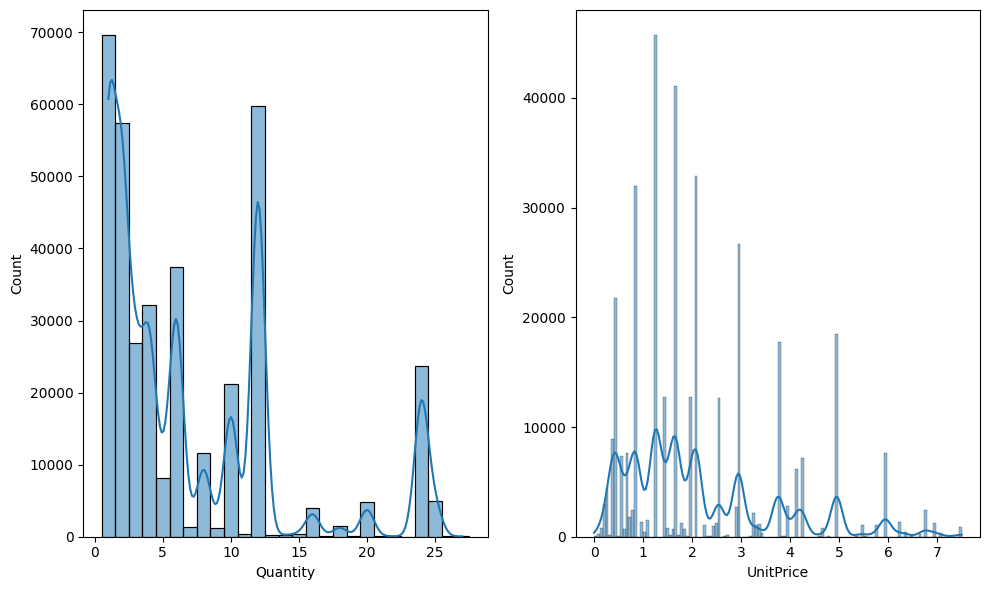

In [161]:
fig, axis = plot.subplots(nrows=1, ncols=2, figsize=(10, 6))

sb.histplot(data_numeric_of_quantity_without_outlier['Quantity'], ax=axis[0], kde=True, bins='fd', discrete=True)
sb.histplot(data_numeric_of_unit_price_without_outlier['UnitPrice'], ax=axis[1], kde=True, bins='fd')

plot.tight_layout()
plot.show()

分布也基本符合右偏分布。